In [2]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.regression.rolling import RollingOLS

import yfinance as yf
import seaborn
import matplotlib.pyplot as plt

In [3]:
#Get Data
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=5)

symbol_list = ['O39.SI', 'D05.SI', 'U11.SI']
data = yf.download(
    symbol_list, 
    start= start_date, 
    end= end_date,
    auto_adjust=False 
)['Adj Close']

[*********************100%***********************]  3 of 3 completed


In [4]:
# Find co-integrated pairs
def find_cointegrated_pairs(data):
    n = data.shape[1]                    #how many cols in the dataframe: 3
    score_matrix = np.zeros((n, n))      #return an array of 0 given the shape, shape: 3x3
    pvalue_matrix = np.ones((n, n))      #return an array of 1s given the shape, shape: 3x3
    keys = data.keys()
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            S1 = data[keys[i]]
            S2 = data[keys[j]]
            result = coint(S1, S2)
            score = result[0]
            pvalue = result[1]
            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            if pvalue < 0.05:
                pairs.append((keys[i], keys[j]))
    return score_matrix, pvalue_matrix, pairs

In [5]:
scores, pvalues, pairs = find_cointegrated_pairs(data)

In [6]:
#pvalues

In [7]:
#pairs

In [8]:
#scores

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


<Axes: >

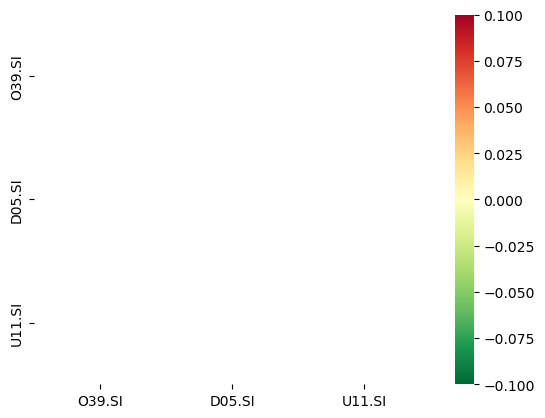

In [9]:
#plot heat map for visualisation
seaborn.heatmap(
    pvalues, 
    xticklabels=symbol_list, 
    yticklabels=symbol_list, 
    cmap='RdYlGn_r', 
    mask = (pvalues >= 0.05)
)

In [13]:
#Model the Spread
S1 = data['D05.SI']
S2 = data['O39.SI']

S1 = sm.add_constant(S1)
results = sm.OLS(S2, S1).fit()
S1 = S1['D05.SI']
b = results.params['D05.SI']
spread = S2 - b * S1

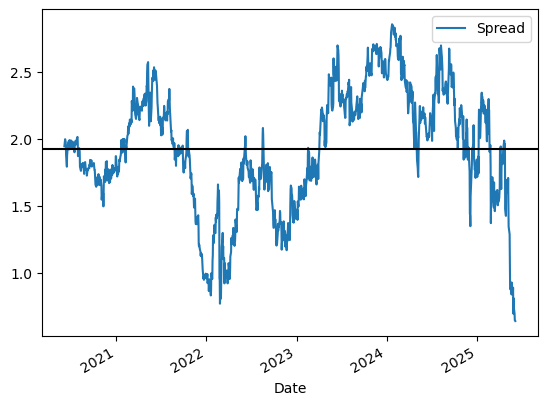

In [14]:
#Model the soread - Plot
spread.plot()
plt.axhline(spread.mean(), color='black')
plt.legend(['Spread']);

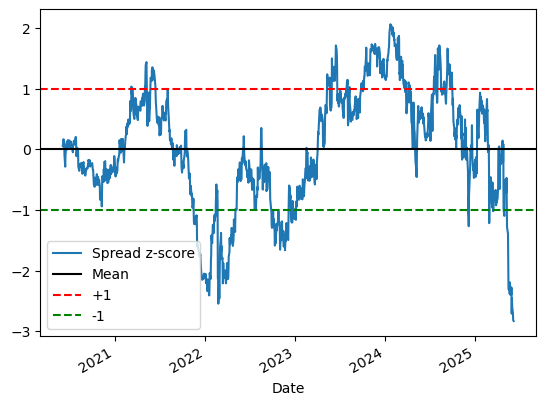

In [15]:
#plot Z-score
def zscore(series):
    return (series - series.mean()) / np.std(series)

zscore(spread).plot()
plt.axhline(zscore(spread).mean(), color='black')
plt.axhline(1.0, color='red', linestyle='--')
plt.axhline(-1.0, color='green', linestyle='--')
plt.legend(['Spread z-score', 'Mean', '+1', '-1']);

<Axes: xlabel='Date'>

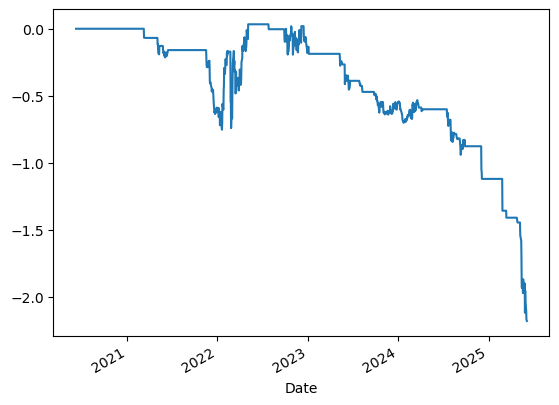

In [16]:
#Implement Trading Strategy
# Create a DataFrmae with the signal and position size in the pair
trades = pd.concat([zscore(spread), S2 - b * S1], axis=1)
trades.columns = ["signal", "position"]

# Add a long and short position at the z-score levels
trades["side"] = 0.0
trades.loc[trades.signal <= -1, "side"] = 1
trades.loc[trades.signal >= 1, "side"] = -1
returns = trades.position.pct_change() * trades.side
returns.cumsum().plot()